<a href="https://colab.research.google.com/github/TanuSree02/Deep-learning/blob/main/LSTM_Program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 170ms/step - accuracy: 0.7957 - loss: 0.4411 - val_accuracy: 0.8094 - val_loss: 0.4376
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 163ms/step - accuracy: 0.8974 - loss: 0.2592 - val_accuracy: 0.8712 - val_loss: 0.3175
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 162ms/step - accuracy: 0.9285 - loss: 0.1938 - val_accuracy: 0.8728 - val_loss: 0.3245
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 163ms/step - accuracy: 0.9463 - loss: 0.1490 - val_accuracy: 0.8724 - val_loss: 0.3737
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 164ms/step - accuracy: 0.9571 - loss: 0.1192 - val_accuracy: 0.8736 - val_loss: 0.4079
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8572 - loss: 0.4443
Test accuracy : 0.8572400212287903


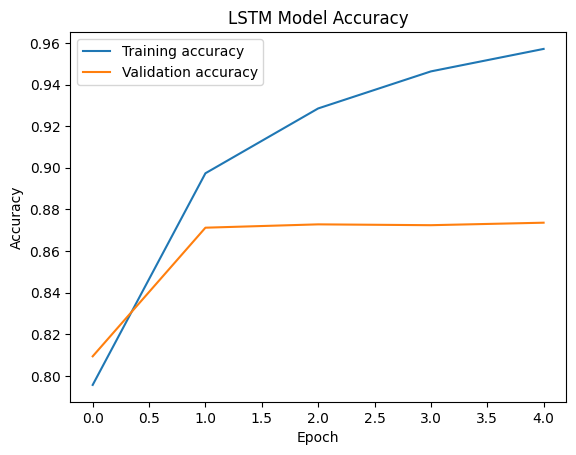

In [1]:
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

import matplotlib.pyplot as plt


vocab_size = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)


max_length = 200

x_train = pad_sequences(
    x_train,
    maxlen=max_length
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length
)


model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    )
)

model.add(
    LSTM(64)
)

model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test accuracy :", accuracy)


plt.plot(
    history.history['accuracy'],
    label="Training accuracy"
)

plt.plot(
    history.history['val_accuracy'],
    label="Validation accuracy"
)

plt.legend()

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("LSTM Model Accuracy")

plt.show()